In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D
from keras.layers import Convolution2D, MaxPooling2D, Dropout
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/object_detection/data/'

categories = ['banh-hoi-heo-quay', 'bun-bo-hue', 'bun-ca', 'bun-dau-mam-tom', 'bun-hai-san-be-be', 'bun-moc', 'bun-muc', 'bun-nuoc-leo',
              'cao-lau', 'com-ga', 'com-tam-long-xuyen', 'hu-tieu-my-tho', 'mi-quang', 'pho-ha-noi']

In [ ]:
data = []
labels = []
imagePaths = []
HEIGHT = 256
WIDTH = 256
N_CHANNELS = 3

for k, category in enumerate(categories):
    for f in os.listdir(path+category):
        imagePaths.append([path+category+'/'+f, k])

In [ ]:
import random
random.seed(42)
random.shuffle(imagePaths)

In [ ]:
for id, imagePath in enumerate(imagePaths):
    print(id)
    image = cv2.imread(imagePath[0])
    image = cv2.resize(image, (WIDTH, HEIGHT))
    data.append(image)
    label = imagePath[1]
    labels.append(label)

data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

In [ ]:
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.3, random_state=42)

trainY = to_categorical(trainY, len(categories))

# DenseNet201

In [ ]:
from keras.applications import DenseNet201

EPOCHS = 45
INIT_LR = 1e-3
BS = 34

class_names = categories

densenet201 = DenseNet201(input_shape=(WIDTH, HEIGHT, 3), include_top=False, weights='imagenet')
for layer in densenet201.layers:
    layer.trainable = False

model = Sequential()
model.add(densenet201)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(len(class_names), activation='softmax'))

opt = tf.keras.optimizers.legacy.Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print(model.summary())

# RestNet101

In [ ]:
from keras.applications import ResNet101

EPOCHS = 40
INIT_LR = 1e-3
BS = 32

class_names = categories

resnet101 = ResNet101(input_shape=(WIDTH, HEIGHT, 3), include_top=False, weights='imagenet')
for layer in resnet101.layers:
    layer.trainable = False

model = Sequential()
model.add(resnet101)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(len(class_names), activation='softmax'))

opt = tf.keras.optimizers.legacy.Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print(model.summary())

# VGG16

In [ ]:
from keras.applications import VGG16

EPOCHS = 45
INIT_LR = 1e-3
BS = 34

class_names = categories

vgg16 = VGG16(input_shape=(WIDTH, HEIGHT, 3), include_top=False, weights='imagenet')
for layer in vgg16.layers:
    layer.trainable = False

model = Sequential()
model.add(vgg16)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(len(class_names), activation='softmax'))

opt = tf.keras.optimizers.legacy.Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print(model.summary())

# MobileNet

In [ ]:
from keras.applications import MobileNet

EPOCHS = 40
INIT_LR = 1e-3
BS = 32

class_names = categories

mobileNet = MobileNet(input_shape=(WIDTH, HEIGHT, 3), include_top=False, weights='imagenet')
for layer in mobileNet.layers:
    layer.trainable = False

model = Sequential()
model.add(mobileNet)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(len(class_names), activation='softmax'))

opt = tf.keras.optimizers.legacy.Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print(model.summary())

# LeNet

In [ ]:
EPOCHS = 40
INIT_LR = 1e-3
BS = 32

class_names = categories


model = Sequential()

model.add(Convolution2D(filters=32, kernel_size=(5,5), padding='same', activation='relu', input_shape=(WIDTH, HEIGHT, 3)))
model.add(MaxPooling2D(strides=2))
model.add(Convolution2D(filters=48, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(MaxPooling2D(strides=2))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(len(class_names), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

# InceptionV3

In [ ]:
EPOCHS = 50
INIT_LR = 1e-3
BS = 34

class_names = categories

from keras.applications import InceptionV3

inceptionV3 = InceptionV3(input_shape=(WIDTH, HEIGHT, 3), include_top=False, weights='imagenet')
for layer in inceptionV3.layers:
    layer.trainable = False

model = Sequential()
model.add(inceptionV3)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(len(class_names), activation='softmax'))
opt = tf.keras.optimizers.legacy.Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 6, 6, 2048)        21802784  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 14)                28686     
                                                                 
Total params: 21831470 (83.28 MB)
Trainable params: 28686 (112.05 KB)
Non-trainable params: 21802784 (83.17 MB)
__________

In [ ]:
model.fit(trainX, trainY, batch_size=BS, epochs=EPOCHS, verbose=1)

In [ ]:
model.save("/content/drive/MyDrive/object_detection/inceptionv3.h5")

In [ ]:
from numpy import argmax
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

pred = model.predict(testX)
predictions = argmax(pred, axis=1) # return to label

# cm = confusion_matrix(testY, predictions)

# fig = plt.figure()
# ax = fig.add_subplot(111)
# cax = ax.matshow(cm)
# plt.title('Model confusion matrix')
# fig.colorbar(cax)
# ax.set_xticklabels([''] + categories)
# ax.set_yticklabels([''] + categories)

# for i in range(len(class_names)):
#     for j in range(len(class_names)):
#         ax.text(i, j, cm[j, i], va='center', ha='center')

# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.show()

In [ ]:
accuracy = accuracy_score(testY, predictions)
print("Accuracy : %.2f%%" % (accuracy*100.0))
print("\n")

In [ ]:
recall= recall_score(testY, predictions,average='weighted')
print("Recall :%.2f%%" % (recall*100))
print("\n")
# ----------------------------------------------

precision = precision_score(testY, predictions,average='weighted')
print("Precision : %.2f%%" % (precision*100.0))
print("\n")
# ----------------------------------------------

f1 = f1_score(testY, predictions,average='weighted')
print("F1 : %.2f%%" % (f1*100.0))
print("\n")

1/1 [==============================] - 0s 40ms/step
[[1.9836922e-04 9.5071381e-01 2.7134307e-03 8.0245860e-05 7.0359935e-03
  1.1504733e-04 7.3316733e-05 5.9511932e-04 3.0709893e-02 5.5545047e-03
  9.3684008e-04 1.9966010e-05 2.8448919e-04 9.6898648e-04]]


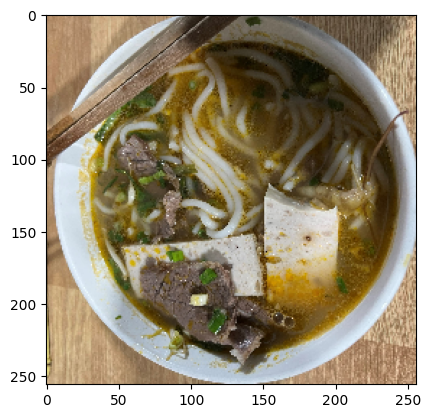

bun-bo-hue 95.07138133049011


In [ ]:
from numpy import argmax
import PIL
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
img_path="./2.jpg"

img=image.load_img(img_path,target_size=(256,256))
img_array=image.img_to_array(img)
from tensorflow.keras.applications.resnet50 import preprocess_input,decode_predictions
img_batch=np.expand_dims(img_array, axis=0)
img_preprocessed=preprocess_input(img_batch)

pred=model.predict(img_preprocessed)
Res=argmax(pred,axis=1)
print(pred)

plt.imshow(img)
plt.show()
print(categories[Res[0]],pred[0][Res[0]]*100)